# Prognózování objemu návštěv pohotovosti pomocí exponenciálního vyrovnávání (PROC ESM)


## Manažerské shrnutí

Středně velký nemocniční systém potřebuje roční prognózu měsíčního objemu návštěv pohotovosti (ED), aby naplánoval obsazení sester a lůžkovou kapacitu před zimní respirační vlnou. Tento notebook sestaví syntetickou čtyřletou měsíční evidenci ED (48 měsíců, leden 2021 - prosinec 2024) a nafituje Wintersův multiplikativní sezónní model pomocí **PROC ESM**, aby vytvořil 12měsíční prognózu s 95% predikčními intervaly.

Fitovaný model zachycuje řadu dobře: vnitrovýběrové **RMSE je asi 320 návštěv** a **MAPE je 4,16 %**, takže typická měsíční chyba je pod 5 % objemu. Prognóza promítá známý sezónní tvar do roku 2025 - vrchol v prosinci až únoru poblíž **7 300-7 800 návštěv/měsíc** a pozdně letní minimum poblíž **5 800-5 900** - s predikčními pásmy, která se s prodlužujícím se horizontem rozšiřují. Tato čísla a vyrovnávací váhy za nimi jsou odečteny přímo z výstupních datových sad procedury níže.


## Zdroje dat

| Datová sada | Řádky | Zrno | Klíčové proměnné | Popis |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Jeden řádek na kalendářní měsíc, leden 2021 - prosinec 2024 | `month` (měsíční SAS datum), `ed_visits` (celočíselný měsíční počet návštěv ED) | Syntetický měsíční objem návštěv pohotovosti pro středně velký nemocniční systém. Generováno s rostoucím trendem (~3 % ročně), multiplikativním sezónním cyklem vrcholícím v zimní respirační sezóně (prosinec-únor) a klesajícím v pozdním létě, plus lognormálním šumem, takže sezónní amplituda škáluje s rostoucí úrovní. |


# Prognózování objemu návštěv pohotovosti pomocí PROC ESM

Plánovači kapacit potřebují vědět, kolik návštěv ED očekávat každý měsíc, aby mohli rozvrhnout sestry, držet flexibilní lůžka a připravit respirační zásoby před zimní vlnou. Objem ED je učebnicová sezónní časová řada: rok od roku pomalu roste, vrcholí během respirační sezóny prosinec-únor a klesá v pozdním létě, přičemž velikost sezónního výkyvu roste s tím, jak roste základní objem. Přesně tuto multiplikativní sezónní strukturu je Wintersova multiplikativní metoda v **PROC ESM** navržena zachytit.

V tomto notebooku:

1. Generujeme realistickou čtyřletou měsíční evidenci ED s trendem, multiplikativní sezónností a šumem.
2. Vizualizujeme řadu, abychom potvrdili její multiplikativní sezónní strukturu.
3. Nafitujeme Wintersův multiplikativní model pomocí PROC ESM a přečteme jeho vyrovnávací váhy a statistiky shody z výstupních datových sad.
4. Vytvoříme prognózu na 12 měsíců dopředu s 95% predikčními intervaly a interpretujeme provozní důsledky.


## Krok 1 - Generování syntetické měsíční evidence ED

Sestavíme 48 měsíčních pozorování od ledna 2021 do prosince 2024. Očekávaný objem každého měsíce je základní úroveň, která roste asi o 3 % ročně, vynásobená sezónním indexem (nejvyšší uprostřed zimy, nejnižší v pozdním létě) a poté rozrušená lognormálním šumem, takže náhodná variabilita škáluje s úrovní. `intnx` posouvá datum zarovnané na měsíc o jednu periodu na řádek a `streaminit` činí losování reprodukovatelným.


In [1]:
data ed_census;
    CALL streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    POLE seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    FORMÁT month yymmn6.;
    OPAKUJ i = 1 TO 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        VÝSTUP;
    KONEC;
    PONECHAT month ed_visits;
SPUSTIT;

PROCEDURA TISK data=ed_census(obs=14) noobs ŠTÍTEK;
    ŠTÍTEK month="Měsíc" ed_visits="Návštěvy pohotovosti";
    NÁZEV "Prvních 14 měsíců syntetického objemu návštěv pohotovosti";
SPUSTIT;

                               Prvních 14 měsíců syntetického objemu návštěv pohotovosti                                

  Měsíc     Návštěvy pohotovosti
 202101                     7103
 202102                     6835
 202103                     6668
 202104                     5611
 202105                     5816
 202106                     5383
 202107                     5586
 202108                     5283
 202109                     5161
 202110                     6109
 202111                     6451
 202112                     6730
 202201                     6847
 202202                     7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


První měsíce potvrzují návrh: objem začíná poblíž 7 100 v lednovém vrcholu 2021, klesá přes jaro a léto ke svému minimu v srpnu-září a poté šplhá zpět do další zimy. Do ledna 2022 se vrchol posunul na asi 6 800-7 200, což odráží ~3% roční růst navrstvený na sezónní cyklus.


## Krok 2 - Vizualizace řady

Před modelováním vykreslíme surovou řadu, abychom potvrdili strukturu, kterou očekáváme: mírný rostoucí trend s opakujícím se ročním vrcholem každou zimu, jehož amplituda se v čase rozšiřuje. Rozšiřující se sezónní výkyv je znakem *multiplikativního* sezónního procesu a říká nám, který model ESM zvolit.


                               Prvních 14 měsíců syntetického objemu návštěv pohotovosti                                




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


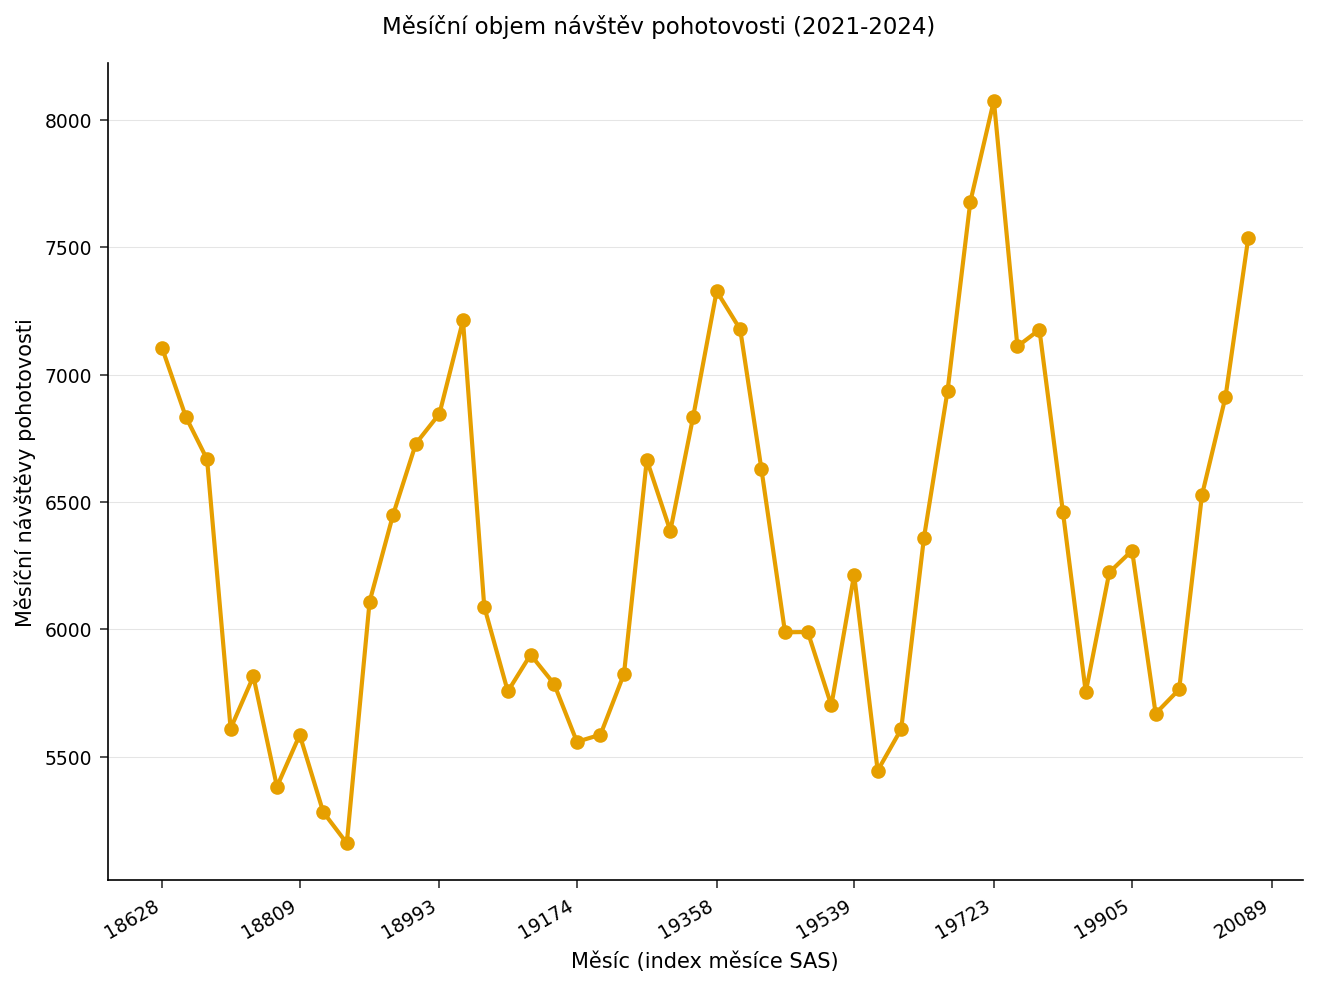

In [2]:
PROCEDURA SGPLOT data=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS ŠTÍTEK="Měsíc (index měsíce SAS)";
    YAXIS ŠTÍTEK="Měsíční návštěvy pohotovosti" grid;
    NÁZEV "Měsíční objem návštěv pohotovosti (2021-2024)";
SPUSTIT;

Graf ukazuje čtyři čisté roční cykly. Každý zimní vrchol leží o něco výše než předchozí, šplhá zhruba ze 7 100 v roce 2021 na asi 8 100 ve vrcholu 2024, zatímco letní minima rostou skromněji - sezónní výkyv roste s úrovní. Tato rozšiřující se amplituda je charakteristickým znakem multiplikativní sezónnosti a ospravedlňuje `MODEL=WINTERS` (Wintersova multiplikativní) v dalším kroku.


## Krok 3 - Fitování Wintersova multiplikativního modelu

Nafitujeme Wintersovo multiplikativní sezónní vyrovnávání na celé 48měsíční historii. Příkaz `ID` deklaruje `month` jako časový index s intervalem `MONTH` a příkaz `FORECAST` vyžádá `MODEL=WINTERS` s `LEAD=12` k promítnutí o rok dopředu. Zachytíme tři výstupní datové sady:

- `OUT=` - historická řada s připojenou prognózou (jeden sloupec `ed_visits`), s časovým ID rozšířeným přes horizont prognózy - ideální pro vykreslení.
- `OUTFOR=` - komponenty prognózy za periodu: bodová prognóza (`PREDICT`) a dolní/horní predikční meze.
- `OUTSUM=` - statistiky shody modelu (RMSE, MAE, MAPE, AIC) a vyrovnávací váhy, v jediném souhrnném řádku.

`ALPHA=0.05` dává 95% predikční meze, vhodné pro rizikové rezervy plánování kapacit. `PRINT=(STATISTICS)` vypíše statistiky shody a vyrovnávací váhy do výpisu.


In [3]:
PROCEDURA esm data=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        print=(statistics);
    id month interval=month;
    forecast ed_visits / MODEL=winters ALPHA=0.05;
SPUSTIT;

PROCEDURA TISK data=esm_summary noobs ŠTÍTEK;
    ŠTÍTEK rmse="RMSE" mae="MAE" mape="MAPE"
          ALPHA="Úroveň (alpha)" beta="Trend (beta)" gamma="Sezóna (gamma)";
    PROMĚNNÁ rmse mae mape ALPHA beta gamma;
    NÁZEV "Statistiky shody a vyrovnávací váhy (Winters)";
SPUSTIT;

                               Prvních 14 měsíců syntetického objemu návštěv pohotovosti                                


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                     Statistiky shody a vyrovnávací váhy (Winters)                                      

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


Řádek `OUTSUM=` a vytištěné statistiky se shodují: Wintersův multiplikativní fit dosahuje vnitrovýběrového **RMSE 320,4 návštěv**, **MAE 264,4** a **MAPE 4,16 %** - typická měsíční chyba pohodlně pod 5 % objemu, což je pro plánování obsazení dostatečně přesné. Vyrovnávací váhy jsou **alpha = 0,30** (úroveň), **beta = 0,10** (trend) a **gamma = 0,10** (sezóna). Střední váha úrovně nechává základ unášet vzhůru s růstem populace pacientů, zatímco malé váhy trendu a sezóny odrážejí, že tempo růstu a tvar zimní vlny jsou rok od roku stabilní a nemělo by se na ně z měsíce na měsíc přehnaně reagovat.

> Poznámka: jde o *vnitrovýběrové* statistiky shody spočítané na odhadovém vzorku, nikoli na out-of-sample kontrolní části. Kvantifikují, jak těsně model sleduje historii, na které byl nafitován.


## Krok 4 - Sestavení a tabelace 12měsíční prognózy

Datová sada `OUTFOR=` obsahuje bodovou prognózu a predikční meze pro každou periodu, zatímco datová sada `OUT=` nese časové ID čistě rozšířené přes horizont prognózy. Obě zarovnáme podle pořadí pozorování, abychom připojili data prognózy k predikčním mezím, a poté ponecháme jen 12 prognózovaných měsíců. To jsou čísla, podle kterých by výbor pro obsazení jednal.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
data out_idx;
    NASTAVIT ed_with_forecast;
    row = _n_;
    PŘEJMENOVAT month = fdate ed_visits = series_value;
SPUSTIT;

data for_idx;
    NASTAVIT esm_forecast;
    row = _n_;
    PŘEJMENOVAT ed_visits = observed;
    PONECHAT row observed predict LOWER UPPER;
SPUSTIT;

data forecast_path;
    SLOUČIT out_idx for_idx;
    PODLE row;
    FORMÁT fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
SPUSTIT;

data forecast_horizon;
    NASTAVIT forecast_path;
    KDE observed = .;   /* forecast months only (no observed value) */
    PONECHAT fdate predict LOWER UPPER;
SPUSTIT;

PROCEDURA TISK data=forecast_horizon noobs ŠTÍTEK;
    ŠTÍTEK fdate   = "Měsíc"
          predict = "Prognóza návštěv"
          LOWER   = "95% dolní mez"
          UPPER   = "95% horní mez";
    NÁZEV "12měsíční prognóza návštěv pohotovosti s 95% predikčními mezemi";
SPUSTIT;

                            12měsíční prognóza návštěv pohotovosti s 95% predikčními mezemi                             

  Měsíc      Prognóza návštěv   95% dolní mez   95% horní mez
 202501                 7,822           7,194           8,450
 202502                 7,539           6,651           8,427
 202503                 7,292           6,204           8,380
 202504                 6,263           5,007           7,519
 202505                 6,397           4,992           7,801
 202506                 6,039           4,501           7,578
 202507                 6,236           4,574           7,897
 202508                 5,867           4,091           7,644
 202509                 5,802           3,918           7,686
 202510                 6,804           4,818           8,790
 202511                 7,173           5,090           9,256
 202512                 7,567           5,391           9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


Prognóza přenáší sezónní signaturu do roku 2025. Model promítá lednový vrchol 2025 na asi **7 822 návštěv** (95% interval 7 194-8 450), uvolňuje se přes jaro, dosahuje dna v pozdně letním minimu poblíž **5 802** v září (interval 3 918-7 686) a poté se dostavuje k prosincovému vrcholu zhruba **7 567** (interval 5 391-9 742). Predikční pásmo se s horizontem stále rozšiřuje - interval příštího měsíce zabírá asi +/-630 návštěv, zatímco příštího prosince přes +/-2 000 - přímá připomínka, že krátkodobé plány jsou mnohem pevnější než ty ke konci roku.


## Krok 5 - Vykreslení historie plus prognózy

Nakonec překryjeme prognózu na pozorovanou historii, aby plánovači viděli promítnutý zimní vrchol a rozšiřující se pásmo nejistoty, jak se horizont prodlužuje. Zarovnanou řadu `forecast_path` rozdělíme na **pozorovanou** historii (plná čára) a **12měsíční prognózu** (přerušovaná čára), aby byl předěl jasný, a pod ní nakreslíme 95% predikční pásmo. Osa x je index měsíčního SAS data, běžící zleva doprava od ledna 2021 do prosince 2025.


                            12měsíční prognóza návštěv pohotovosti s 95% predikčními mezemi                             




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


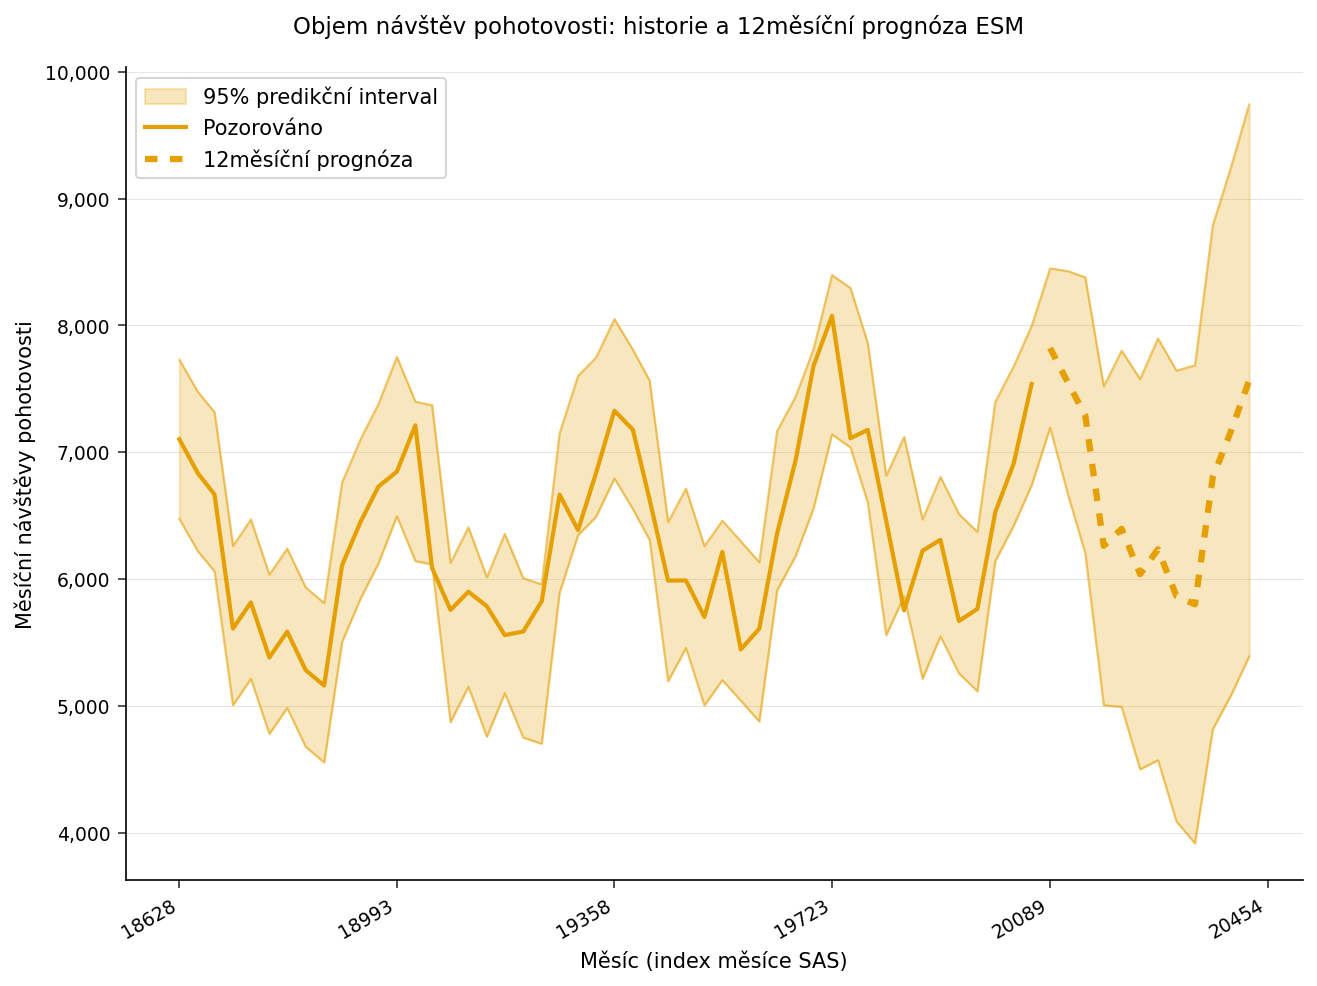

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
data forecast_plot;
    NASTAVIT forecast_path;
    KDYŽ observed = . PAK fc_only = predict;   /* future months only */
    JINAK fc_only = .;
SPUSTIT;

PROCEDURA SGPLOT data=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel="95% predikční interval" TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel="Pozorováno";
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel="12měsíční prognóza";
    XAXIS ŠTÍTEK="Měsíc (index měsíce SAS)";
    YAXIS ŠTÍTEK="Měsíční návštěvy pohotovosti" grid;
    NÁZEV "Objem návštěv pohotovosti: historie a 12měsíční prognóza ESM";
SPUSTIT;

## Interpretace výsledků

Wintersův multiplikativní model rozkládá objem ED na pomalu rostoucí **úroveň**, téměř plochý **trend** a stabilní **sezónní** vzorec. Vyrovnávací váhy odečtené z `OUTSUM=` vyprávějí příběh: střední váha úrovně (alpha = 0,30) nechává základ unášet vzhůru s růstem populace pacientů, zatímco malé váhy trendu a sezóny (beta = gamma = 0,10) odrážejí, že tempo růstu a tvar zimní vlny jsou rok od roku velmi stabilní a nemělo by se na ně z měsíce na měsíc přehnaně reagovat.

**Statistiky shody** potvrzují, že model sleduje historii dobře: RMSE asi 320 návštěv a MAPE 4,16 % znamenají, že typická měsíční chyba je pod 5 % objemu. Provozně **tabulka prognózy a graf pásma** kvantifikují vrchol prosinec-únor, na který by pohotovost měla obsazovat - zhruba 7 300-7 800 návštěv v zimních měsících - a 95% predikční meze vymezují uvážlivé kapacitní rozpětí: plánujte základní obsazení na bodovou prognózu a předem zajistěte flexibilní krytí a přetlaková lůžka směrem k horní mezi. Interval se s horizontem rozšiřuje, takže plán příštího měsíce je mnohem pevnější než plán příštího prosince a měl by se s příchodem nových skutečných hodnot obnovovat.

**Rozšíření:** porovnejte `MODEL=ADDWINTERS` (aditivní sezónnost) proti multiplikativnímu fitu pro potvrzení volby multiplikativního modelu; aplikujte `TRANSFORM=LOG` pro vynucení kladnosti a stabilizaci rozptylu; nebo přidejte příkaz `BY` pro prognózování více nemocničních pracovišť v jediném volání PROC ESM.
